<a href="https://colab.research.google.com/github/brysonje/DS_Training/blob/main/Analysis%26Visualization/M1_I_tabular_data_exploration_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# path = "https://www.openml.org/data/get_csv/3608/dataset_183_adult.csv"
path = "https://www.openml.org/data/get_csv/1595261/phpMawTba.csv"

In [3]:
adult_census = pd.read_csv(path)
adult_census.drop("fnlwgt", axis = 1, inplace = True)
adult_census.shape

(48842, 14)

In [4]:
adult_census.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [5]:
adult_census.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [6]:
target_column = "class"
adult_census[target_column].value_counts()

,count
class,
<=50K,37155
>50K,11687


In [7]:
numerical_columns = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_columns = ["workclass", "education", "marital-status", "occupation", "relationship",
                       "race", "sex", "native-country"]
all_columns = numerical_columns + categorical_columns + [target_column]
adult_census = adult_census[all_columns]

In [8]:
print(f"The dataset contains {adult_census.shape[0]} samples and " f"{adult_census.shape[1]} columns")

The dataset contains 48842 samples and 14 columns


In [9]:
print(f"The dataset contains {adult_census.shape[1] - 1} features.")

The dataset contains 13 features.


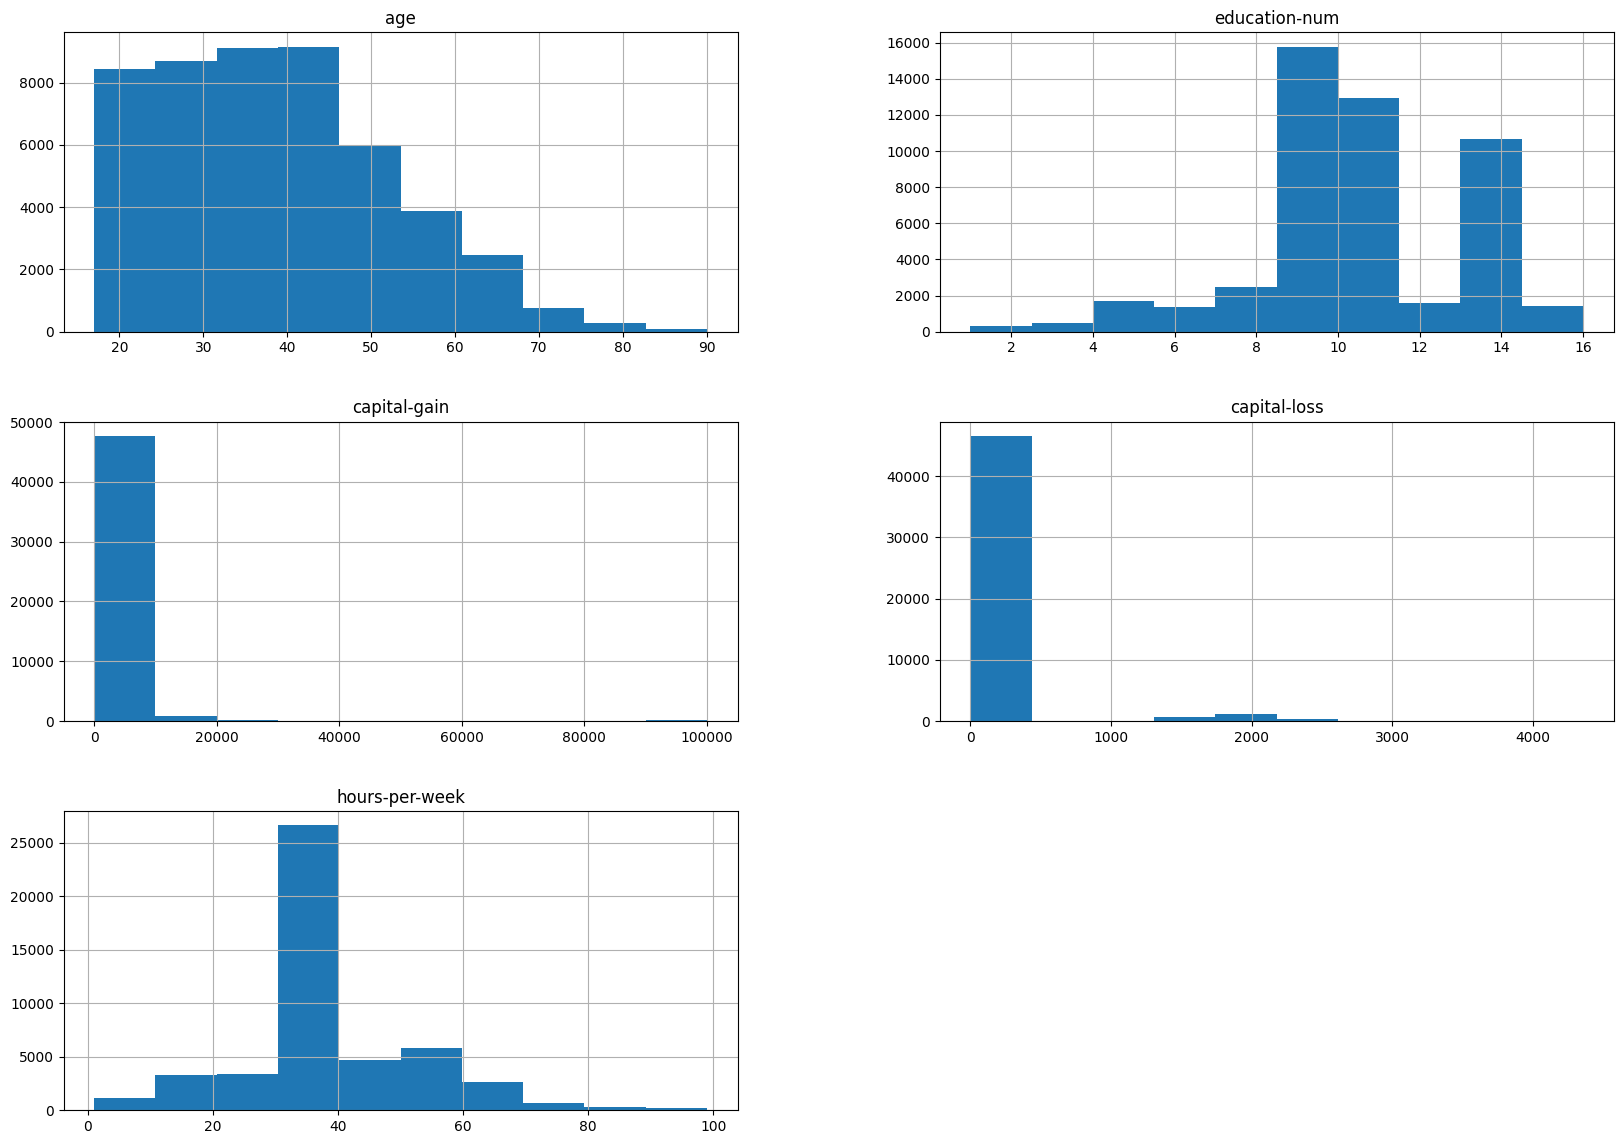

In [10]:
graph1 = adult_census.hist(figsize=(20, 14))

In [11]:
adult_census["sex"].value_counts()

,count
sex,
Male,32650
Female,16192


In [12]:
adult_census["education"].value_counts()

,count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [13]:
pd.crosstab(index=adult_census["education"], columns=adult_census["education-num"])

education-num,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
education,,,,,,,,,,,,,,,,
10th,0,0,0,0,0,1389,0,0,0,0,0,0,0,0,0,0
11th,0,0,0,0,0,0,1812,0,0,0,0,0,0,0,0,0
12th,0,0,0,0,0,0,0,657,0,0,0,0,0,0,0,0
1st-4th,0,247,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5th-6th,0,0,509,0,0,0,0,0,0,0,0,0,0,0,0,0
7th-8th,0,0,0,955,0,0,0,0,0,0,0,0,0,0,0,0
9th,0,0,0,0,756,0,0,0,0,0,0,0,0,0,0,0
Assoc-acdm,0,0,0,0,0,0,0,0,0,0,0,1601,0,0,0,0
Assoc-voc,0,0,0,0,0,0,0,0,0,0,2061,0,0,0,0,0


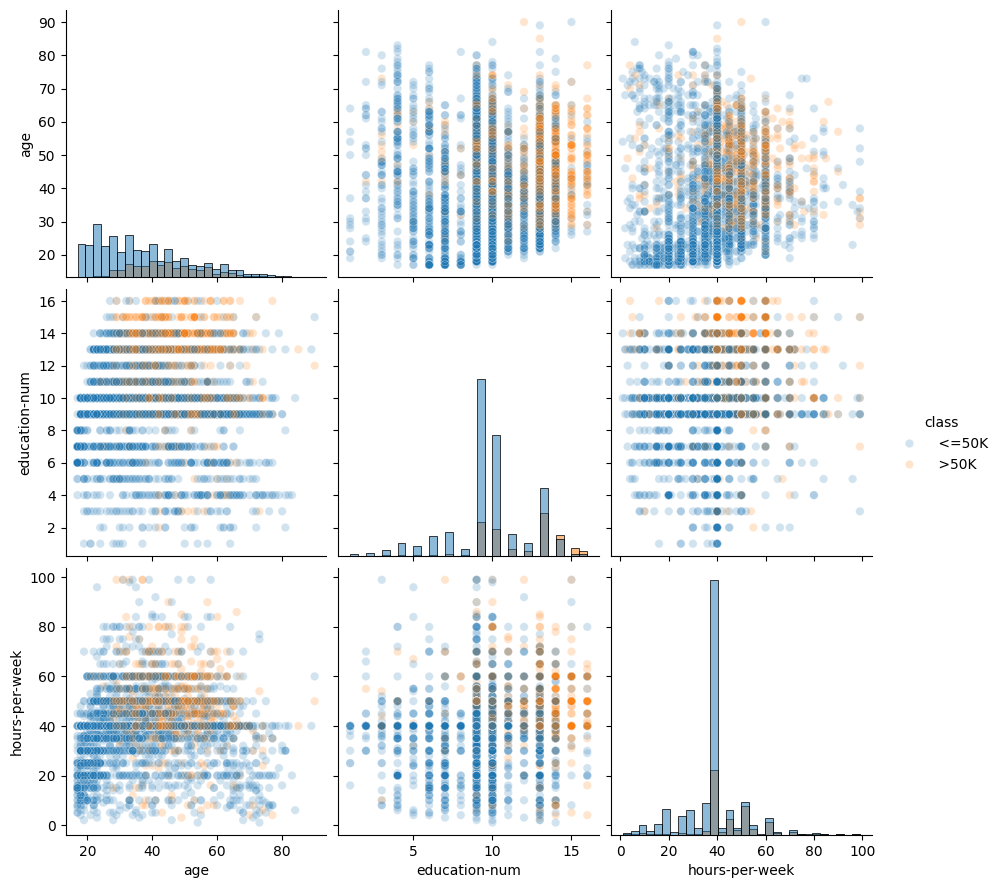

In [14]:
# We will plot a subset of the data to keep the plot readable and make the plotting faster
n_samples_to_plot = 5000
columns = ["age", "education-num", "hours-per-week"]
graph2 = sns.pairplot(data = adult_census[:n_samples_to_plot], vars = columns, hue = target_column,
                 plot_kws = {"alpha": 0.2}, height = 3, diag_kind = "hist", diag_kws = {"bins": 30})

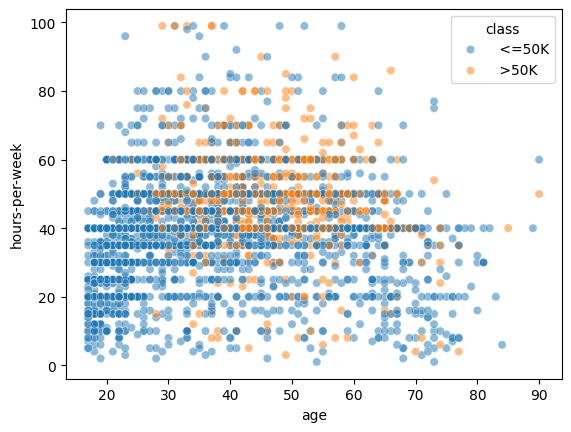

In [15]:
graph3 = sns.scatterplot(x = "age", y = "hours-per-week", data = adult_census[:n_samples_to_plot],
                         hue = "class", alpha = 0.5)

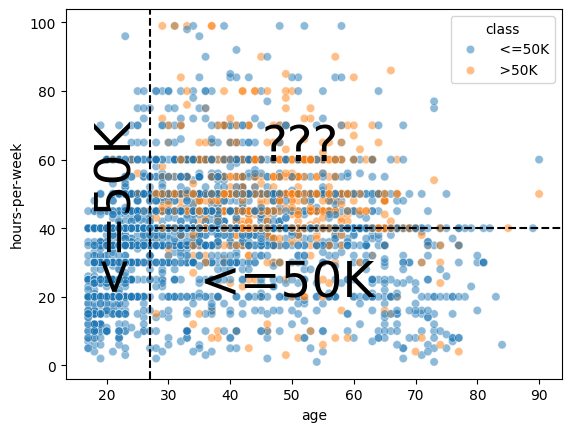

In [16]:
ax = sns.scatterplot(x = "age", y = "hours-per-week", data = adult_census[:n_samples_to_plot],
                     hue = "class", alpha=0.5)
age_limit = 27
plt.axvline(x = age_limit, ymin = 0, ymax = 1, color = "black", linestyle = "--")
hours_per_week_limit = 40
plt.axhline(y = hours_per_week_limit, xmin = 0.18, xmax = 1, color = "black", linestyle = "--")
plt.annotate("<=50K", (17, 25), rotation = 90, fontsize = 35)
plt.annotate("<=50K", (35, 20), fontsize = 35)
graph4 = plt.annotate("???", (45, 60), fontsize = 35)